# Astra Training Study
Bucle de entrenamiento espejo de `train.py` (Fisher Sampler + Smart Refinement).

In [1]:
import os, sys
sys.path.append('..')

import torch, numpy as np, matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.auto import tqdm

from opensplat3d.utils.train_utils import setup_training, FisherCameraSampler
from opensplat3d.scene import Scene
from opensplat3d.gaussian_model import create_from_pcd
from opensplat3d.gaussian_optimizer import GaussianOptimizer
from opensplat3d.gaussian_renderer import render
from opensplat3d.losses import l1_loss, ssim, instance_2d_loss, get_erank_loss, get_thinness_loss
from opensplat3d.data import load_scene_info
from opensplat3d.utils.vis_utils import pca, enhance_image

device = torch.device('cuda:0')

class Args:
    config = '/home/jsm15/opensplat3d/configs/astra_lab.yaml'
    overrides = [
        'model.source_path=/home/jsm15/datasets/astra_lab/astra_lab_0.db3',
        'model.model_path=output/training_astra'
    ]
    wandb = None; checkpoint = None

config = setup_training(Args())
model_params = config.model; opt_params = config.opt; pipe_params = config.pipe

scene_info = load_scene_info(model_params)
scene = Scene(scene_info, model_params.resolution, device)
gaussians = create_from_pcd(scene_info.point_cloud, model_params.sh_degree, device, 
                            model_params.mask_subdir is not None, model_params.mask_dim, 
                            opt_params.feature_init, opt_params.static_xyz)
optimizer = GaussianOptimizer(gaussians, opt_params, model_params.sh_degree, 
                              scene.cameras_extent, opt_params.static_xyz, device)
sampler = FisherCameraSampler(scene.get_train_cameras())
background = torch.tensor([0, 0, 0], dtype=torch.float32, device=device)
print(f'Setup OK. Camaras cargadas: {len(sampler.cameras)}')


Using fused SSIM
Found ROS2 Bag, assuming ROS2 dataset!
[ROS2Reader] Indexing bag: /home/jsm15/datasets/astra_lab/astra_lab_0.db3


Scanning Bag (Metadata): 58073it [00:01, 29453.13it/s]


[ROS2Reader] Timestamp ranges:
  Color: 1776693030289333217 to 1776693358552960563 (Duration: 328.26s)
  Depth: 1776693030300202651 to 1776693358528359438 (Duration: 328.23s)
  [!] TF Frame 'base_link' DOES NOT OVERLAP with color images!
      TF: 1776693029533620829 to 1776693029533620829
  [!] TF Frame 'astra_camera_link' DOES NOT OVERLAP with color images!
      TF: 1776693029533620829 to 1776693029533620829
  [!] TF Frame 'laser_back' DOES NOT OVERLAP with color images!
      TF: 1776693029533620829 to 1776693029533620829
  [!] TF Frame 'laser_front' DOES NOT OVERLAP with color images!
      TF: 1776693029533620829 to 1776693029533620829
  [!] TF Frame 'body_link' DOES NOT OVERLAP with color images!
      TF: 1776693029533620829 to 1776693029533620829
  [!] TF Frame 'nose_camera_link' DOES NOT OVERLAP with color images!
      TF: 1776693029533620829 to 1776693029533620829
  [!] TF Frame 'head_link' DOES NOT OVERLAP with color images!
      TF: 1776693029533620829 to 177669302953362

Scanning Bag (Data): 19727it [00:02, 9322.85it/s] 


[ROS2Reader] Successfully indexed 1000 synced frames.
[ROS2Reader] Loading 1000 cameras from bag...


...

Train: 1000 | Test: 0
Sampled 200000/200000 points from the point cloud.
Loading Training Cameras


  0%|          | 0/1000 [00:00<?, ?it/s]

Loading Test Cameras


0it [00:00, ?it/s]

Number of points at initialisation: 200000
Setup OK. Camaras cargadas: 1000


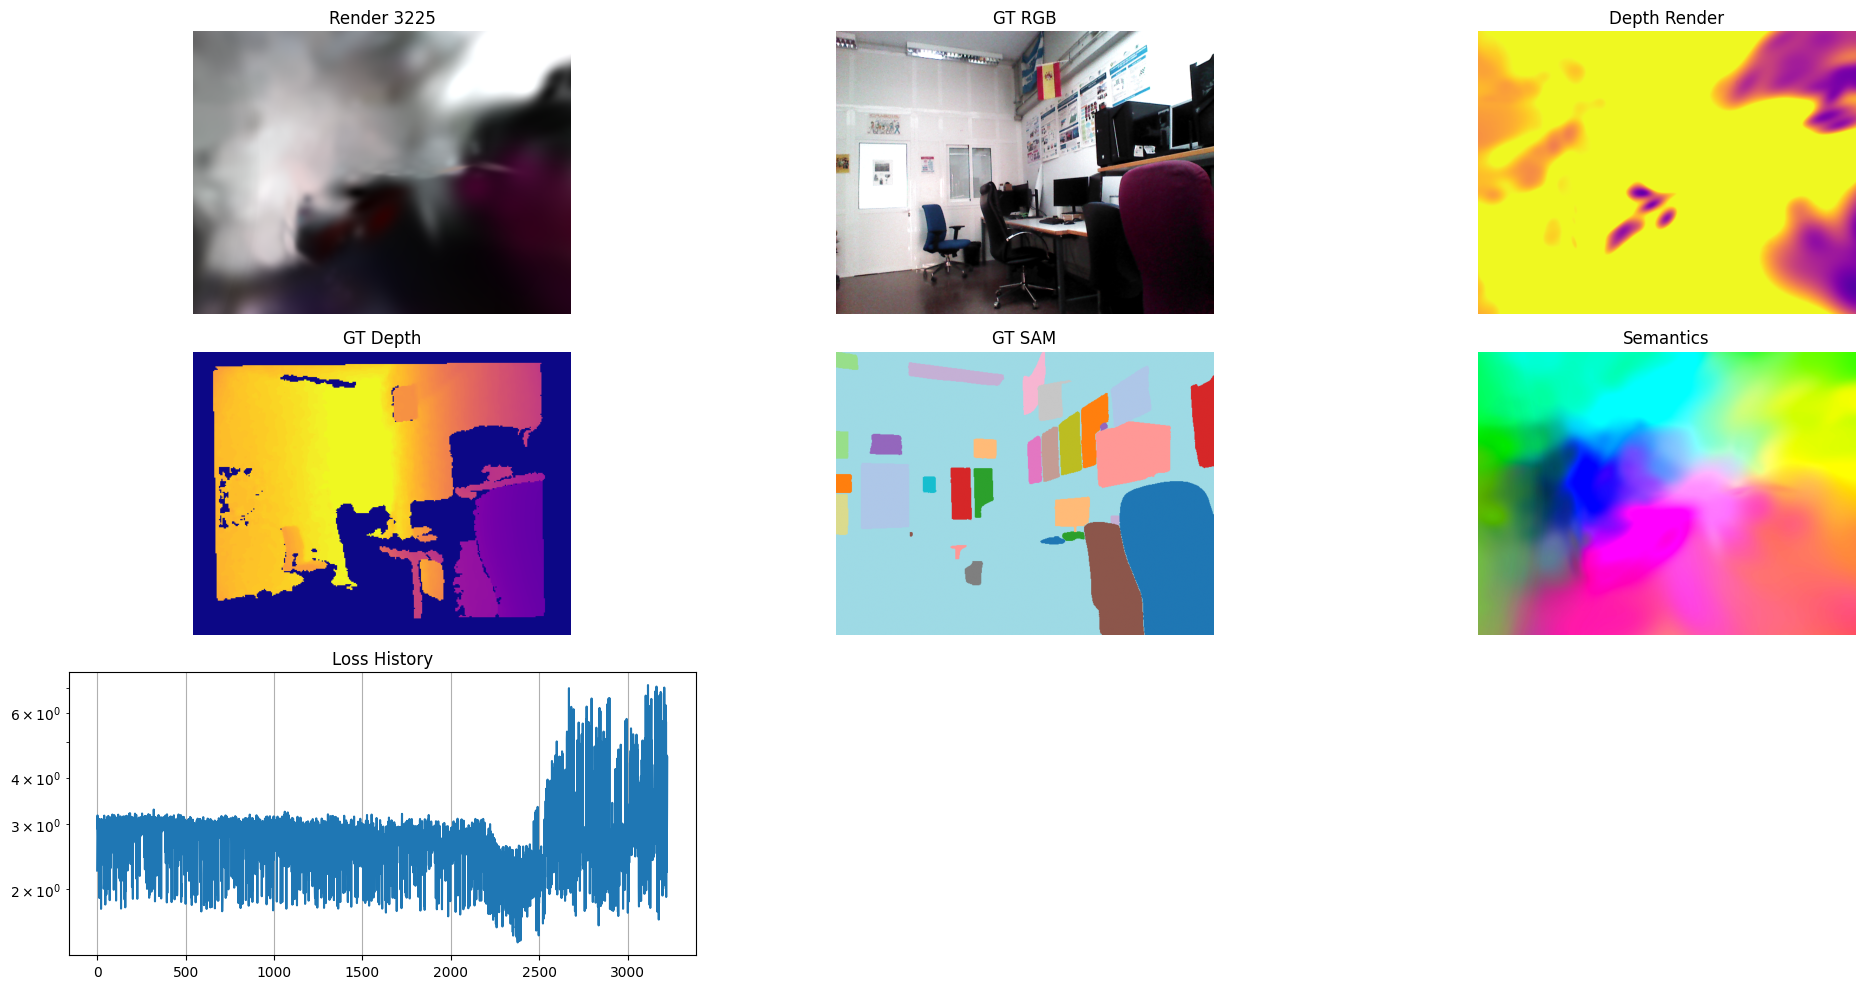

Iter 3225 | Loss: 3.618401 | Pts: 203818 | Depth L1: 4.3291e+00


KeyboardInterrupt: 

In [2]:
ITERS = 10000; DISP = 25; losses = []; ema_loss = 0.0; mask_dim = model_params.mask_dim

p_bar = tqdm(range(1, ITERS + 1), desc='Training')
for iteration in p_bar:
    optimizer.update_learning_rate(iteration)
    if iteration % 1000 == 0: optimizer.oneup_sh_degree()
    
    viewpoint_cam = sampler.sample()
    bg = torch.rand(3, device=device) if opt_params.random_background else background
    bg_f = torch.rand(mask_dim, device=device) if opt_params.random_background_features else None
    has_depth = (viewpoint_cam.original_depth is not None)
    
    pkg = render(viewpoint_cam, gaussians, pipe_params, bg, model_params.sh_degree, 
                 optimizer.active_sh_degree, bg_features=bg_f, render_color=True, 
                 render_features=True, render_depth=has_depth, render_var=True)
    
    gt_img = viewpoint_cam.original_image.to(device)
    L1 = l1_loss(pkg.render, gt_img)
    photo_l = (1.0 - opt_params.lambda_dssim) * L1 + opt_params.lambda_dssim * (1.0 - ssim(pkg.render, gt_img))
    loss = opt_params.photo_lambda * photo_l
    
    d_l_v = 0.0
    if has_depth:
        d_l = l1_loss(pkg.depth, viewpoint_cam.original_depth.to(device))
        d_l_v = d_l.item(); loss += opt_params.lambda_depth * d_l
    
    if pkg.variance is not None: loss += opt_params.var_lambda * pkg.variance[:mask_dim].pow(2).mean()
    
    if viewpoint_cam.masks is not None and iteration % opt_params.inst2d_interval == 0:
        i2d = instance_2d_loss(pkg.features[:mask_dim], viewpoint_cam.masks.to(device), mask_dim, 
                               opt_params.inst2d_sample_size, opt_params.inst2d_gamma, 
                               opt_params.inst2d_weights, opt_params.inst2d_normalize)
        loss += opt_params.inst2d_lambda * i2d['total']
    
    warm = min(1.0, iteration / 2000)
    loss += warm * (opt_params.lambda_erank * get_erank_loss(gaussians.get_scaling) + 
                    opt_params.lambda_thin * get_thinness_loss(gaussians.get_scaling))
    
    optimizer.optimizer.zero_grad(set_to_none=True); loss.backward()
    with torch.no_grad():
        optimizer.add_stats(pkg.viewspace_points, pkg.visibility_filter, pkg.radii, pkg.viewspace_points.grad, None)
        vis = pkg.visibility_filter
        surprise = ((pkg.viewspace_points.grad[vis, :2] ** 2).sum(-1, keepdim=True) / (optimizer.fim_accum[vis] + 0.01)).sum().item()
        sampler.update_score(viewpoint_cam.uid, surprise)
        if iteration > opt_params.densify_from_iter and iteration % opt_params.densification_interval == 0:
            optimizer.densify_and_prune(opt_params.densify_grad_threshold, 0.005, scene.cameras_extent, None)
        if iteration % opt_params.opacity_reset_interval == 0:
            optimizer.reset_opacity()
        optimizer.optimizer.step(); losses.append(loss.item()); ema_loss = 0.4 * loss.item() + 0.6 * ema_loss
    
    if iteration % DISP == 0:
        clear_output(wait=True); plt.figure(figsize=(20, 10))
        H, W = gt_img.shape[1], gt_img.shape[2]
        def show(pos, img, title, **kw):
            plt.subplot(3,3,pos); plt.imshow(img, **kw); plt.title(title); plt.axis('off')
        
        # Fila 1: RGB y Depth
        show(1, pkg.render.detach().permute(1,2,0).cpu().clamp(0,1), f"Render {iteration}")
        show(2, gt_img.permute(1,2,0).cpu().clamp(0,1), "GT RGB")
        show(3, pkg.depth.detach().cpu(), "Depth Render", cmap='plasma', vmin=0, vmax=5)
        
        # Fila 2: SAM, Semantics y Loss
        show(4, viewpoint_cam.original_depth.cpu() if has_depth else np.zeros((H,W)), "GT Depth", cmap="plasma", vmin=0, vmax=5)
        show(5, viewpoint_cam.masks.cpu().numpy()%20 if viewpoint_cam.masks is not None else np.zeros((H,W)), "GT SAM", cmap='tab20')
        f_ = pkg.features[:mask_dim].permute(1,2,0).cpu().detach().numpy(); p_ = pca(f_.reshape(-1, mask_dim), 3, True).reshape(H,W,3)
        show(6, enhance_image((p_*255).astype(np.uint8)), "Semantics")
        plt.subplot(3,3,7); plt.plot(losses); plt.yscale('log'); plt.title("Loss History"); plt.grid(True)
        
        plt.tight_layout(); plt.show()
        print(f"Iter {iteration} | Loss: {ema_loss:.6f} | Pts: {gaussians.num_points} | Depth L1: {d_l_v:.4e}")
